In [1]:
import pandas as pd

In [2]:
df_icare = pd.read_excel(r"C:\Users\afpue\OneDrive\Documentos\GitHub\causalidad\Codigo\df_icare.xlsx")

In [3]:
df_icare

,submitdate,Wave,startdate,datestamp,sex,age,edu,emplstat_sq001,emplstat_sq002,emplstat_sq003,...,govmeas_6,govmeas_7,govmeas_8,govmeas_9,govmeas_10,livekidsm,livead,livekids,actfreq_sq009,actfreq_sq025
0,2020-03-31 11:09:05.000,1,2020-03-31 10:34:43.997,2020-03-31 11:09:05.000,2,42.0,4.0,0,0,0,...,3.0,10.0,1.0,5.0,2.0,0.0,0.0,0.0,1.0,1.0
1,2020-03-31 11:15:36.996,1,2020-03-31 10:36:07.001,2020-03-31 11:15:36.996,2,19.0,2.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,1.0,3.0,1.0,NaN,1.0
2,2020-03-31 13:27:39.004,1,2020-03-31 12:57:36.000,2020-03-31 13:27:39.004,2,20.0,2.0,0,0,0,...,9.0,6.0,NaN,NaN,NaN,1.0,3.0,1.0,1.0,1.0
3,2020-03-31 18:23:24.000,1,2020-03-31 17:57:09.999,2020-03-31 18:23:24.000,2,50.0,3.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0,1.0,1.0
4,2020-03-31 18:24:59.999,1,2020-03-31 18:12:30.997,2020-03-31 18:24:59.999,2,40.0,4.0,0,0,0,...,5.0,9.0,NaN,NaN,NaN,2.0,1.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1662,2020-08-13 15:43:06.997,5,2020-08-13 15:10:42.004,2020-08-13 15:43:06.997,1,21.0,3.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,1.0
1663,2020-08-14 19:41:16.996,5,2020-08-14 19:18:04.997,2020-08-14 19:41:16.996,2,32.0,4.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,NaN,1.0
1664,2020-08-15 12:40:38.001,5,2020-08-15 12:23:53.998,2020-08-15 12:40:38.001,2,34.0,4.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0
1665,2020-08-15 13:45:00.996,5,2020-08-15 13:25:00.002,2020-08-15 13:45:00.996,2,25.0,3.0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.0,NaN,1.0


In [4]:
vars = ["sex", "age", "edu", "kidpar"]
tratamiento = "recgov_sq007"
target = "actfreq_sq007"

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf

# ============================
# CONFIG
# ============================

vars = ["sex", "age", "edu"]
tratamiento = "recgov_sq003"
target = "actfreq_sq003"

df = df_icare.copy()

# ============================
# LIMPIEZA
# ============================

# Tratamiento: solo Yes / No
df = df[df[tratamiento].isin([1,2])]

# Outcome válido
df = df[df[target].isin([1,2])]

# Variables binarias
df["T"] = (df[tratamiento] == 1).astype(int)   # 1 = Yes
df["Y"] = (df[target] == 1).astype(int)        # 1 = evento

# Tamaños de grupo
print("\n=== SAMPLE SIZES ===")
print(df["T"].value_counts())

# ============================
# 1. BALANCE DE COVARIABLES
# ============================

balance_rows = []

for v in vars:
    treated = df.loc[df["T"]==1, v]
    control = df.loc[df["T"]==0, v]
    
    mean_t = treated.mean()
    sd_t   = treated.std()
    mean_c = control.mean()
    sd_c   = control.std()
    
    tstat, pval = ttest_ind(treated, control, nan_policy="omit")
    
    balance_rows.append([
        v, mean_t, sd_t, mean_c, sd_c, mean_t-mean_c, pval
    ])

balance_table = pd.DataFrame(
    balance_rows,
    columns=[
        "Variable",
        "Mean_Treated","SD_Treated",
        "Mean_Control","SD_Control",
        "Diff","p_value"
    ]
)

print("\n=== BALANCE TABLE ===")
print(balance_table)

# ============================
# 2. DIFERENCIA DE MEDIAS OUTCOME
# ============================

meanY_T = df.loc[df["T"]==1, "Y"].mean()
meanY_C = df.loc[df["T"]==0, "Y"].mean()

ATE_diff = meanY_T - meanY_C

tstat_Y, pval_Y = ttest_ind(
    df.loc[df["T"]==1, "Y"],
    df.loc[df["T"]==0, "Y"],
    nan_policy="omit"
)

print("\n=== OUTCOME DIFFERENCE ===")
print("Mean Y Treated :", meanY_T)
print("Mean Y Control :", meanY_C)
print("ATE (diff)     :", ATE_diff)
print("p-value        :", pval_Y)

# ============================
# 3. REGRESION SIMPLE
# ============================

m1 = smf.ols("Y ~ T", data=df).fit()

print("\n=== REGRESSION Y ~ T ===")
print(m1.summary())

print("\nATE (coef T):", m1.params["T"])
print("p-value:", m1.pvalues["T"])

# ============================
# 4. REGRESION AJUSTADA
# ============================

m2 = smf.ols(
    "Y ~ T + C(sex) + age + C(edu)",
    data=df
).fit()

print("\n=== REGRESSION ADJUSTED ===")
print(m2.summary())

print("\nATE adjusted:", m2.params["T"])
print("p-value:", m2.pvalues["T"])



=== SAMPLE SIZES ===
T
1    1506
0     103
Name: count, dtype: int64

=== BALANCE TABLE ===
  Variable  Mean_Treated  SD_Treated  Mean_Control  SD_Control      Diff  \
0      sex      1.678619    0.467162      1.728155    0.468501 -0.049536   
1      age     34.914741   13.283768     40.233010   13.046075 -5.318269   
2      edu      3.215569    0.806992      3.456311    0.638268 -0.240742   

    p_value  
0  0.298053  
1  0.000087  
2  0.003077  

=== OUTCOME DIFFERENCE ===
Mean Y Treated : 0.8665338645418327
Mean Y Control : 0.2621359223300971
ATE (diff)     : 0.6043979422117356
p-value        : 3.319274816040474e-60

=== REGRESSION Y ~ T ===
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     291.6
Date:                Thu, 12 

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf

# ============================
# CONFIG
# ============================

vars = ["sex", "age", "edu"]
tratamiento = "recgov_sq003"
target = "actfreq_sq003"

df = df_icare.copy()

# ============================
# LIMPIEZA Y SAMPLING
# ============================

# 1. Filtros básicos
# Tratamiento: solo Yes / No
df = df[df[tratamiento].isin([1,2])]

# Outcome válido
df = df[df[target].isin([1,2])]

# Variables binarias
df["T"] = (df[tratamiento] == 1).astype(int)   # 1 = Yes (70% target)
df["Y"] = (df[target] == 1).astype(int)        # 1 = evento

# ---------------------------------------------------------
# 2. RECORTE DE MUESTRA (70% Tratados / 30% Control)
# ---------------------------------------------------------

# Separar los grupos
df_treated = df[df["T"] == 1]
df_control = df[df["T"] == 0]

n_treated = len(df_treated)
n_control = len(df_control)

# Lógica:
# Queremos que Control sea el 30% del TOTAL final.
# Ratio: n_control / n_treated = 30 / 70 = 3/7
# Por tanto: n_control_deseado = n_treated * (3/7)
# O viceversa: n_treated_deseado = n_control * (7/3)

# Calculamos cuántos controles necesitaríamos dado el nº de tratados actuales
req_control = int(n_treated * (30/70))

if n_control >= req_control:
    # CASO A: Tenemos suficientes (o sobran) controles. 
    # Mantenemos todos los tratados (1) y recortamos los controles (0).
    df_treated_final = df_treated
    df_control_final = df_control.sample(n=req_control, random_state=123)
else:
    # CASO B: No hay suficientes controles para soportar tantos tratados.
    # Mantenemos todos los controles (0) y recortamos los tratados (1).
    req_treated = int(n_control * (70/30))
    df_control_final = df_control
    df_treated_final = df_treated.sample(n=req_treated, random_state=123)

# Reconstruir el DataFrame
df = pd.concat([df_treated_final, df_control_final]).sample(frac=1, random_state=123).reset_index(drop=True)

# ---------------------------------------------------------

# Tamaños de grupo resultantes
print("\n=== SAMPLE SIZES (TARGET: 70% T=1, 30% T=0) ===")
counts = df["T"].value_counts()
print(counts)
print(f"Prop. Control (0): {counts[0]/len(df):.2%}")
print(f"Prop. Treated (1): {counts[1]/len(df):.2%}")

# ============================
# 1. BALANCE DE COVARIABLES
# ============================

balance_rows = []

for v in vars:
    treated = df.loc[df["T"]==1, v]
    control = df.loc[df["T"]==0, v]
    
    mean_t = treated.mean()
    sd_t   = treated.std()
    mean_c = control.mean()
    sd_c   = control.std()
    
    # Check para evitar errores si la varianza es 0 o n es muy pequeño tras el recorte
    if len(treated) > 1 and len(control) > 1:
        tstat, pval = ttest_ind(treated, control, nan_policy="omit")
    else:
        pval = np.nan
    
    balance_rows.append([
        v, mean_t, sd_t, mean_c, sd_c, mean_t-mean_c, pval
    ])

balance_table = pd.DataFrame(
    balance_rows,
    columns=[
        "Variable",
        "Mean_Treated","SD_Treated",
        "Mean_Control","SD_Control",
        "Diff","p_value"
    ]
)

print("\n=== BALANCE TABLE ===")
print(balance_table)

# ============================
# 2. DIFERENCIA DE MEDIAS OUTCOME
# ============================

meanY_T = df.loc[df["T"]==1, "Y"].mean()
meanY_C = df.loc[df["T"]==0, "Y"].mean()

ATE_diff = meanY_T - meanY_C

tstat_Y, pval_Y = ttest_ind(
    df.loc[df["T"]==1, "Y"],
    df.loc[df["T"]==0, "Y"],
    nan_policy="omit"
)

print("\n=== OUTCOME DIFFERENCE ===")
print("Mean Y Treated :", meanY_T)
print("Mean Y Control :", meanY_C)
print("ATE (diff)     :", ATE_diff)
print("p-value        :", pval_Y)

# ============================
# 3. REGRESION SIMPLE
# ============================

m1 = smf.ols("Y ~ T", data=df).fit()

print("\n=== REGRESSION Y ~ T ===")
print(m1.summary())

print("\nATE (coef T):", m1.params["T"])
print("p-value:", m1.pvalues["T"])

# ============================
# 4. REGRESION AJUSTADA
# ============================

m2 = smf.ols(
    "Y ~ T + C(sex) + age + C(edu)",
    data=df
).fit()

print("\n=== REGRESSION ADJUSTED ===")
print(m2.summary())

print("\nATE adjusted:", m2.params["T"])
print("p-value:", m2.pvalues["T"])


=== SAMPLE SIZES (TARGET: 70% T=1, 30% T=0) ===
T
1    240
0    103
Name: count, dtype: int64
Prop. Control (0): 30.03%
Prop. Treated (1): 69.97%

=== BALANCE TABLE ===
  Variable  Mean_Treated  SD_Treated  Mean_Control  SD_Control      Diff  \
0      sex      1.683333    0.466148      1.728155    0.468501 -0.044822   
1      age     34.870833   13.771445     40.233010   13.046075 -5.362176   
2      edu      3.183333    0.792046      3.456311    0.638268 -0.272977   

    p_value  
0  0.415609  
1  0.000876  
2  0.002148  

=== OUTCOME DIFFERENCE ===
Mean Y Treated : 0.8958333333333334
Mean Y Control : 0.2621359223300971
ATE (diff)     : 0.6336974110032363
p-value        : 1.746743653932678e-40

=== REGRESSION Y ~ T ===
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least S

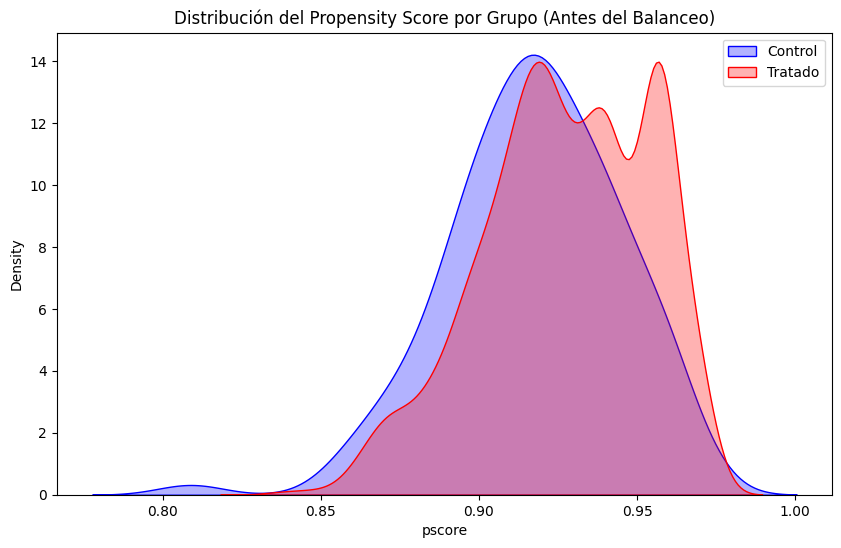

C:\Users\afpue\AppData\Local\Temp\ipykernel_1844\3274860669.py:92: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_match_idx = distances.idxmin()


KeyError: nan

In [13]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# ==========================================
# 1. PREPARACIÓN DE DATOS
# ==========================================
# Si no tienes tus datos cargados, generamos unos sintéticos para el ejemplo
if 'df_icare' not in locals():
    np.random.seed(42)
    N = 1000
    # Covariables: Edad, Sexo, Educación
    age = np.random.normal(55, 10, N)
    sex = np.random.binomial(1, 0.5, N) 
    edu = np.random.choice([1, 2, 3], N)
    
    # Tratamiento (T) depende de las covariables (sesgo de selección)
    # P(T=1) aumenta con edad y educación
    ps_true = 1 / (1 + np.exp(-( -3 + 0.06*age + 0.5*edu )))
    T = np.random.binomial(1, ps_true)
    
    # Outcome (Y) depende de T y covariables
    # Efecto real del tratamiento = 2.5
    Y = 10 + 2.5*T + 0.1*age + 1.5*sex + np.random.normal(0, 3, N)
    
    df = pd.DataFrame({'age': age, 'sex': sex, 'edu': edu, 'T': T, 'Y': Y})
else:
    df = df_icare.copy() # Usar tus datos

# Definir variables
covariates = ['age', 'sex', 'edu'] # Tus covariables
treatment = "recgov_sq003"
outcome = "actfreq_sq003"                  # Tu variable de respuesta
# Convert treatment to binary (1 and 2 -> 1 and 0)
df[treatment] = (df[treatment] == 1).astype(int)

# ==========================================
# 2. ESTIMACIÓN DEL PROPENSITY SCORE (PS)
# ==========================================
# Rosenbaum & Rubin: El PS es la probabilidad condicional de recibir tratamiento dado X.
formula_ps = f"{treatment} ~ {' + '.join(covariates)}"
ps_model = smf.logit(formula_ps, data=df).fit(disp=0)
df['pscore'] = ps_model.predict(df)

# Visualizar Solapamiento (Common Support)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df[treatment]==0], x='pscore', fill=True, label='Control', color='blue', alpha=0.3)
sns.kdeplot(data=df[df[treatment]==1], x='pscore', fill=True, label='Tratado', color='red', alpha=0.3)
plt.title('Distribución del Propensity Score por Grupo (Antes del Balanceo)')
plt.legend()
plt.show()

# ==========================================
# 3. EVALUACIÓN DE BALANCE (SMD)
# ==========================================
def calculate_smd(data, treat_col, covs):
    """Calcula la Diferencia de Medias Estandarizada (Standardized Mean Difference)"""
    smd_list = []
    for cov in covs:
        t = data[data[treat_col]==1][cov]
        c = data[data[treat_col]==0][cov]
        diff = t.mean() - c.mean()
        pool_sd = np.sqrt((t.var() + c.var()) / 2)
        smd_list.append({'Variable': cov, 'SMD': abs(diff / pool_sd)})
    return pd.DataFrame(smd_list)

smd_before = calculate_smd(df, treatment, covariates)

# ==========================================
# MÉTODO A: EMPAREJAMIENTO (MATCHING)
# ==========================================
# Implementación simple de vecino más cercano (Nearest Neighbor)
# Nota: Para datos reales complejos, usar bibliotecas como CausalInference es ideal.

treated = df[df[treatment] == 1].copy()
control = df[df[treatment] == 0].copy()

matched_indices_t = []
matched_indices_c = []
control_used = set()

for t_idx in treated.index:
    ps_t = treated.loc[t_idx, 'pscore']
    # Buscar control disponible más cercano
    control_candidates = control[~control.index.isin(control_used)]
    if not control_candidates.empty:
        # Calcular distancia absoluta
        distances = abs(control_candidates['pscore'] - ps_t)
        best_match_idx = distances.idxmin()
        
        # Guardar si la distancia es razonable (caliper simple opcional)
        if distances[best_match_idx] < 0.2: 
            matched_indices_t.append(t_idx)
            matched_indices_c.append(best_match_idx)
            control_used.add(best_match_idx)

df_matched = pd.concat([df.loc[matched_indices_t], df.loc[matched_indices_c]])

# Calcular Balance Post-Matching
smd_after = calculate_smd(df_matched, treatment, covariates)

# ATE por Matching
ate_matching = df_matched[df_matched[treatment]==1][outcome].mean() - \
               df_matched[df_matched[treatment]==0][outcome].mean()

# ==========================================
# GRÁFICOS DE BALANCE (LOVE PLOT & DISTRIBUCIONES)
# ==========================================

# 1. Love Plot (Cambio en SMD)
plt.figure(figsize=(8, 5))
plt.plot(smd_before['SMD'], smd_before['Variable'], 'o', label='Antes', color='red', alpha=0.6)
plt.plot(smd_after['SMD'], smd_after['Variable'], 'o', label='Después (Matching)', color='blue', alpha=0.6)
plt.axvline(0.1, color='black', linestyle='--', alpha=0.3, label='Umbral Recomendado (0.1)')
plt.title('Mejora en el Balance de Covariables (Love Plot)')
plt.xlabel('Diferencia de Medias Estandarizada (SMD)')
plt.legend()
plt.show()

# 2. Distribución de una covariable clave (ej. Age) Antes vs Después
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes
sns.boxplot(x=treatment, y='age', data=df, ax=axes[0])
axes[0].set_title('Distribución Edad: Original')

# Después
sns.boxplot(x=treatment, y='age', data=df_matched, ax=axes[1])
axes[1].set_title('Distribución Edad: Después del Matching')
plt.show()

# ==========================================
# COMPARACIÓN DE MÉTODOS (ATE y REGRESIÓN)
# ==========================================

# 1. Naive (Sin ajustar)
model_naive = smf.ols(f"{outcome} ~ {treatment}", data=df).fit()
ate_naive = model_naive.params[treatment]

# 2. Método B: Subclasificación (Stratification)
# Crear 5 estratos (quintiles) basado en PS
df['strata'] = pd.qcut(df['pscore'], 5, labels=[1,2,3,4,5])
strata_ate_list = []
weights = []

for s in range(1, 6):
    df_s = df[df['strata'] == s]
    if df_s[treatment].nunique() == 2:
        diff = df_s[df_s[treatment]==1][outcome].mean() - df_s[df_s[treatment]==0][outcome].mean()
        weight = len(df_s) / len(df)
        strata_ate_list.append(diff)
        weights.append(weight)

ate_stratification = np.average(strata_ate_list, weights=weights)

# 3. Método C: Ajuste por Covarianza con PS (Regression Adjustment)
# Modelo: Y ~ T + PropensityScore
model_cov_adj = smf.ols(f"{outcome} ~ {treatment} + pscore", data=df).fit()
ate_cov_adj = model_cov_adj.params[treatment]

print("\n" + "="*40)
print(" RESULTADOS DE LA COMPARACIÓN")
print("="*40)
print(f"1. Estimación Naive (Sesgada):     {ate_naive:.4f}")
print(f"2. Matching (Vecino Cercano):      {ate_matching:.4f}")
print(f"3. Subclasificación (5 Estratos):  {ate_stratification:.4f}")
print(f"4. Ajuste de Covarianza por PS:    {ate_cov_adj:.4f}")
print("-" * 40)
print("Coeficientes de la Regresión (Método 4 - Ajuste por PS):")
print(model_cov_adj.params)
print("="*40)

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# --- CARGAR TUS DATOS ---
# df = df_icare.copy()
# covariates = ['sex', 'age', 'edu']
# treatment = 'recgov_sq003'
# outcome = 'actfreq_sq003'

def get_balance_stats(df, stage_name):
    """Calcula medias y desviaciones estándar por grupo"""
    # Agrupar por tratamiento (0=Control, 1=Tratado)
    stats = df.groupby('T')[covariates].agg(['mean', 'std']).T
    
    # Organizar tabla
    data = []
    for cov in covariates:
        c_mean = stats.loc[(cov, 'mean'), 0]
        c_std = stats.loc[(cov, 'std'), 0]
        t_mean = stats.loc[(cov, 'mean'), 1]
        t_std = stats.loc[(cov, 'std'), 1]
        
        data.append({
            'Etapa': stage_name,
            'Variable': cov,
            'Media Control': f"{c_mean:.2f} ({c_std:.2f})",
            'Media Tratado': f"{t_mean:.2f} ({t_std:.2f})",
            'Diferencia': t_mean - c_mean
        })
    return pd.DataFrame(data)

# 1. CALCULAR PROPENSITY SCORE
ps_model = smf.logit("T ~ age + sex + edu", data=df).fit(disp=0)
df['pscore'] = ps_model.predict(df)

# 2. BALANCE ORIGINAL
tabla_orig = get_balance_stats(df, "Original")

# 3. BALANCE MATCHING (Vecino más cercano simple)
treated = df[df['T'] == 1]
control = df[df['T'] == 0]
matched_indices = []
# (Lógica simplificada de matching para el ejemplo)
for i, t_row in treated.iterrows():
    # Buscar el control más cercano
    dists = abs(control['pscore'] - t_row['pscore'])
    min_dist_idx = dists.idxmin()
    if dists[min_dist_idx] < 0.05: # Caliper
        matched_indices.append(i)            # Índice Tratado
        matched_indices.append(min_dist_idx) # Índice Control
        
df_matched = df.loc[matched_indices]
tabla_matched = get_balance_stats(df_matched, "Post-Matching")

# 4. RESULTADOS FINALES
tabla_final = pd.concat([tabla_orig, tabla_matched])
print(tabla_final)

# 5. REGRESIONES
print("Naive ATE:", smf.ols("Y ~ T", data=df).fit().params['T'])
print("Matched ATE:", smf.ols("Y ~ T", data=df_matched).fit().params['T'])
print("PS Adjusted ATE:", smf.ols("Y ~ T + pscore", data=df).fit().params['T'])

           Etapa Variable Media Control Media Tratado  Diferencia
0       Original      age  51.40 (9.51)  56.46 (9.56)    5.065060
1       Original      sex   0.50 (0.50)   0.52 (0.50)    0.022686
2       Original      edu   1.74 (0.81)   2.06 (0.83)    0.323028
0  Post-Matching      age  56.14 (9.39)  56.46 (9.56)    0.329626
1  Post-Matching      sex   0.50 (0.50)   0.52 (0.50)    0.016021
2  Post-Matching      edu   2.10 (0.83)   2.06 (0.83)   -0.038718
Naive ATE: 3.086021576443385
Matched ATE: 2.6688252857690378
PS Adjusted ATE: 2.533892039507101


In [19]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind

# ==========================================
# 1. CONFIGURACIÓN Y LIMPIEZA
# ==========================================
df = df_icare.copy()

# Variables definidas por el usuario
covariates = ['sex', 'age', 'edu']
treatment = 'recgov_sq003'
outcome = 'actfreq_sq003'

# IMPORTANTE: Eliminar NAs en las columnas relevantes para evitar errores
df = df.dropna(subset=covariates + [treatment, outcome]).copy()

# Asegurar que el Tratamiento sea 0 y 1 (Binario)
# Si tus datos son 1 y 2, esto lo convierte a 0 y 1.
# Ajusta esta lógica si tus valores son diferentes (ej. "Yes"/"No")
if df[treatment].min() > 0:
    df['T'] = (df[treatment] == df[treatment].max()).astype(int)
else:
    df['T'] = df[treatment].astype(int)

# ==========================================
# 2. ESTIMACIÓN DEL PROPENSITY SCORE
# ==========================================
# Fórmula: T ~ sex + age + edu
ps_formula = f"T ~ {' + '.join(covariates)}"

# Ajuste del modelo Logit
ps_model = smf.logit(ps_formula, data=df).fit(disp=0)
df['pscore'] = ps_model.predict(df)

# ==========================================
# 3. ALGORITMO DE MATCHING (Vecino más cercano)
# ==========================================
treated = df[df['T'] == 1].copy()
control = df[df['T'] == 0].copy()

matched_t_idx = []
matched_c_idx = []
used_control = set()

# Iterar sobre cada caso tratado para buscarle un gemelo en el control
for t_idx in treated.index:
    ps_t = treated.loc[t_idx, 'pscore']
    
    # Filtrar controles que aún no han sido usados (sin reemplazo)
    available_control = control[~control.index.isin(used_control)]
    
    if available_control.empty:
        break
    
    # Calcular distancias
    distances = abs(available_control['pscore'] - ps_t)
    best_match_idx = distances.idxmin()
    
    # Opcional: Caliper (Umbral máximo de distancia, ej. 0.05)
    # Si la distancia es muy grande, no es un buen match.
    if distances[best_match_idx] < 0.05:
        matched_t_idx.append(t_idx)
        matched_c_idx.append(best_match_idx)
        #used_control.add(best_match_idx)

# Crear el DataFrame Balanceado
df_matched = pd.concat([df.loc[matched_t_idx], df.loc[matched_c_idx]])

print(f"Parejas encontradas: {len(df_matched)//2} de {len(treated)} tratados originales.")

# ==========================================
# 4. GENERACIÓN DE TABLAS
# ==========================================

# --- FUNCION AUXILIAR PARA CALCULAR ESTADISTICAS ---
def get_stats(data, group_col, var_list):
    rows = []
    for var in var_list:
        # Separar grupos
        grp1 = data[data[group_col] == 1][var]
        grp0 = data[data[group_col] == 0][var]
        
        # Test de hipótesis (t-test)
        t_stat, p_val = ttest_ind(grp1, grp0, nan_policy='omit')
        
        rows.append({
            'Variable': var,
            'Mean T': grp1.mean(),
            'SD T': grp1.std(),
            'Mean C': grp0.mean(),
            'SD C': grp0.std(),
            'P-value': p_val
        })
    return pd.DataFrame(rows)

# --- TABLA 1: BALANCE DE COVARIABLES ---
stats_orig = get_stats(df, 'T', covariates)
stats_match = get_stats(df_matched, 'T', covariates)

# Unir y renombrar para la tabla final
stats_orig = stats_orig.add_suffix(' (Orig)').rename(columns={'Variable (Orig)': 'Variable'})
stats_match = stats_match.add_suffix(' (Match)').rename(columns={'Variable (Match)': 'Variable'})

tabla_balance = pd.merge(stats_orig, stats_match, on='Variable')

# --- TABLA 2: DIFERENCIA DE MEDIAS DEL OUTCOME ---
def get_outcome_row(data, label):
    t_mean = data[data['T']==1][outcome].mean()
    c_mean = data[data['T']==0][outcome].mean()
    return {
        'Dataset': label,
        'Mean Treated': t_mean,
        'Mean Control': c_mean,
        'Difference (ATE)': t_mean - c_mean
    }

tabla_outcome = pd.DataFrame([
    get_outcome_row(df, 'Original (Unmatched)'),
    get_outcome_row(df_matched, 'Matched Sample')
])

# --- TABLA 3: REGRESIONES ---
reg_results = []

# Modelo 1: Naive (Original)
m1 = smf.ols(f"{outcome} ~ T", data=df).fit()
reg_results.append(['Naive (Original)', m1.params['T'], m1.pvalues['T'], m1.conf_int().loc['T',0], m1.conf_int().loc['T',1]])

# Modelo 2: Matched (Solo datos emparejados)
m2 = smf.ols(f"{outcome} ~ T", data=df_matched).fit()
reg_results.append(['Matched Simple', m2.params['T'], m2.pvalues['T'], m2.conf_int().loc['T',0], m2.conf_int().loc['T',1]])

# Modelo 3: Ajuste por Propensity Score (Rosenbaum & Rubin Corollary 4.3)
m3 = smf.ols(f"{outcome} ~ T + pscore", data=df).fit()
reg_results.append(['PS Adjustment (Original)', m3.params['T'], m3.pvalues['T'], m3.conf_int().loc['T',0], m3.conf_int().loc['T',1]])

tabla_regresion = pd.DataFrame(reg_results, columns=['Model', 'Coef (ATE)', 'P-value', 'CI Lower', 'CI Upper'])

# ==========================================
# 5. VISUALIZACIÓN DE RESULTADOS
# ==========================================
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n" + "="*80)
print("TABLA 1: COMPARACIÓN DE BALANCE (MEDIA, SD Y P-VALOR)")
print("Revisa si los P-val (Match) son > 0.05 (indica buen balance)")
print("="*80)
print(tabla_balance.round(4).to_string(index=False))

print("\n" + "="*80)
print("TABLA 2: DIFERENCIA DE MEDIAS EN OUTCOME")
print("="*80)
print(tabla_outcome.round(4).to_string(index=False))

print("\n" + "="*80)
print("TABLA 3: RESULTADOS DE REGRESIONES")
print("Comparación de coeficientes y significancia estadística")
print("="*80)
print(tabla_regresion.round(4).to_string(index=False))

Parejas encontradas: 103 de 103 tratados originales.

TABLA 1: COMPARACIÓN DE BALANCE (MEDIA, SD Y P-VALOR)
Revisa si los P-val (Match) son > 0.05 (indica buen balance)
Variable  Mean T (Orig)  SD T (Orig)  Mean C (Orig)  SD C (Orig)  P-value (Orig)  Mean T (Match)  SD T (Match)  Mean C (Match)  SD C (Match)  P-value (Match)
     sex         1.7282       0.4685         1.6786       0.4672          0.2983          1.7282        0.4685          1.7282        0.4471           1.0000
     age        40.2330      13.0461        34.9092      13.2842          0.0001         40.2330       13.0461         40.1359       12.5464           0.9566
     edu         3.4563       0.6383         3.2156       0.8070          0.0031          3.4563        0.6383          3.4563        0.6227           1.0000

TABLA 2: DIFERENCIA DE MEDIAS EN OUTCOME
             Dataset  Mean Treated  Mean Control  Difference (ATE)
Original (Unmatched)        1.7379        1.1337            0.6041
      Matched Sample   

In [18]:
df['actfreq_sq003']

0       2.0
1       2.0
2       2.0
3       2.0
4       2.0
       ... 
1662    1.0
1663    1.0
1664    1.0
1665    1.0
1666    1.0
Name: actfreq_sq003, Length: 1606, dtype: float64

In [17]:
df['pscore']

0       0.091360
1       0.032428
2       0.033199
3       0.085320
4       0.087401
          ...   
1662    0.031926
1663    0.073076
1664    0.076440
1665    0.048327
1666    0.069849
Name: pscore, Length: 1606, dtype: float64

In [12]:
df.columns

Index(['submitdate', 'Wave', 'startdate', 'datestamp', 'sex', 'age', 'edu', 'emplstat_sq001', 'emplstat_sq002', 'emplstat_sq003',
       ...
       'govmeas_8', 'govmeas_9', 'govmeas_10', 'livekidsm', 'livead', 'livekids', 'actfreq_sq009', 'actfreq_sq025', 'T', 'pscore'], dtype='object', length=202)

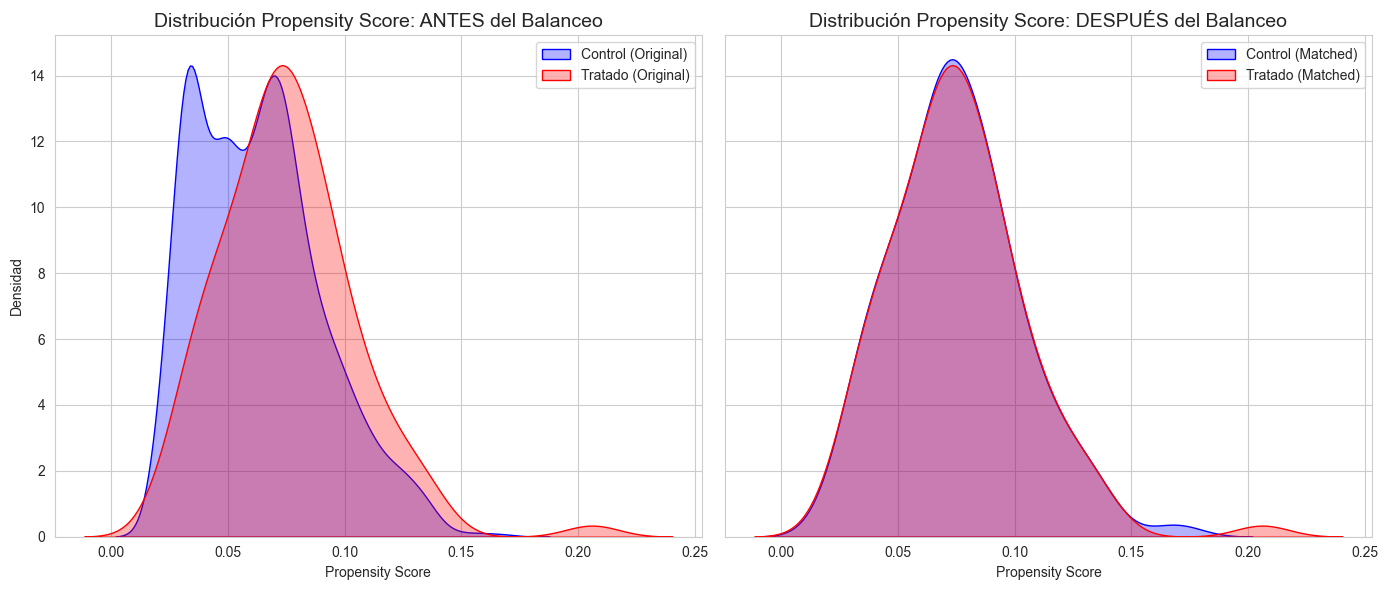

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_style("whitegrid")

# Crear una figura con dos subplots (lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# ---------------------------------------------------------
# GRÁFICO 1: ANTES DEL BALANCEO (Datos Originales: df)
# ---------------------------------------------------------
sns.kdeplot(
    data=df[df['T'] == 0], 
    x='pscore', 
    fill=True, 
    label='Control (Original)', 
    color='blue', 
    alpha=0.3, 
    ax=axes[0]
)
sns.kdeplot(
    data=df[df['T'] == 1], 
    x='pscore', 
    fill=True, 
    label='Tratado (Original)', 
    color='red', 
    alpha=0.3, 
    ax=axes[0]
)
axes[0].set_title('Distribución Propensity Score: ANTES del Balanceo', fontsize=14)
axes[0].set_xlabel('Propensity Score')
axes[0].set_ylabel('Densidad')
axes[0].legend(loc='upper right')

# ---------------------------------------------------------
# GRÁFICO 2: DESPUÉS DEL BALANCEO (Datos Emparejados: df_matched)
# ---------------------------------------------------------
sns.kdeplot(
    data=df_matched[df_matched['T'] == 0], 
    x='pscore', 
    fill=True, 
    label='Control (Matched)', 
    color='blue', 
    alpha=0.3, 
    ax=axes[1]
)
sns.kdeplot(
    data=df_matched[df_matched['T'] == 1], 
    x='pscore', 
    fill=True, 
    label='Tratado (Matched)', 
    color='red', 
    alpha=0.3, 
    ax=axes[1]
)
axes[1].set_title('Distribución Propensity Score: DESPUÉS del Balanceo', fontsize=14)
axes[1].set_xlabel('Propensity Score')
axes[1].legend(loc='upper right')

# Ajustes finales y mostrar
plt.tight_layout()
plt.show()